<a href="https://colab.research.google.com/github/bhavana155/ML_LAB/blob/main/Task4_inlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# Load dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
housing_raw = pd.read_csv(url)

X_housing = housing_raw.drop("medv", axis=1)
y_housing = housing_raw["medv"]

# Standardize features
scaler_housing = StandardScaler()
X_housing_scaled = scaler_housing.fit_transform(X_housing)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_housing_scaled,
    y_housing,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (404, 13)
Test set shape: (102, 13)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test data
lr_preds = lr_model.predict(X_test)

# Evaluate the model
lr_mse = mean_squared_error(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"Mean Squared Error (MSE): {lr_mse:.4f}")
print(f"Mean Absolute Error (MAE): {lr_mae:.4f}")
print(f"R² Score: {lr_r2:.4f}")

Mean Squared Error (MSE): 24.2911
Mean Absolute Error (MAE): 3.1891
R² Score: 0.6688


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test data
dt_preds = dt_model.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_preds)
dt_r2 = r2_score(y_test, dt_preds)

print(f"Decision Tree Regressor Test MSE: {dt_mse:.4f}")
print(f"Decision Tree Regressor R² Score: {dt_r2:.4f}")

Decision Tree Regressor Test MSE: 10.4161
Decision Tree Regressor R² Score: 0.8580


In [ ]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create the Random Forest model
rf = RandomForestRegressor(random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
rf_preds = rf.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regression MSE:", rf_mse)
print("Random Forest Regression R² Score:", rf_r2)

Random Forest Regression MSE: 7.9271453333333355
Random Forest Regression R² Score: 0.891903226702447


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Initialize SVR model
svr_model = SVR()
svr_model.fit(X_train, y_train)

# Predict on test data
svr_preds = svr_model.predict(X_test)

# Evaluate the model
svr_mse = mean_squared_error(y_test, svr_preds)
svr_r2 = r2_score(y_test, svr_preds)

print(f"Support Vector Regression MSE: {svr_mse:.4f}")
print(f"Support Vector Regression R² Score: {svr_r2:.4f}")

Support Vector Regression MSE: 25.6930
Support Vector Regression R² Score: 0.6496


In [ ]:
#Task2
comparison_df = pd.DataFrame({
    'Regression Model': [
        'Support Vector Regression',
        'Decision Tree Regressor'
    ],
    'R² Score': [
        svr_r2,
        dt_r2
    ],
    'Mean Squared Error (MSE)': [
        svr_mse,
        dt_mse
    ]
})

print("--- Performance Comparison ---")
print(comparison_df.to_string(index=False))

--- Performance Comparison ---
         Regression Model  R² Score  Mean Squared Error (MSE)
Support Vector Regression  0.649643                 25.693037
  Decision Tree Regressor  0.857963                 10.416078


In [ ]:
#Task3
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression")
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression
MAE: 3.1890919658878487
MSE: 24.29111947497351
RMSE: 4.928602182665336
R² Score: 0.6687594935356321


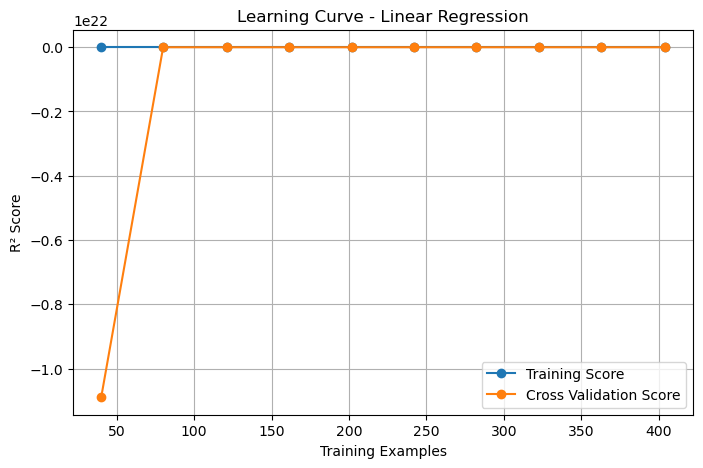

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_housing_scaled,
    y_housing,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='o', label='Cross Validation Score')

plt.title("Learning Curve - Linear Regression")
plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_mae = mean_absolute_error(y_test, dt_preds)
dt_mse = mean_squared_error(y_test, dt_preds)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_preds)

print("Decision Tree Regressor")
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Regressor
MAE: 2.394117647058824
MSE: 10.416078431372549
RMSE: 3.2273949915330395
R² Score: 0.8579634380978161


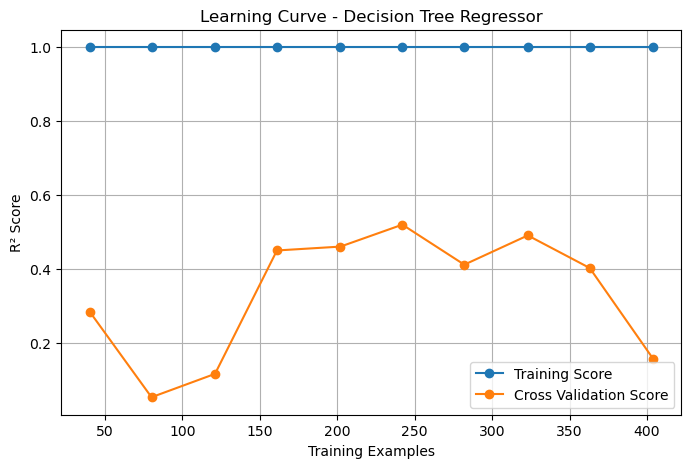

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeRegressor
import numpy as np

model = DecisionTreeRegressor(random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_housing_scaled,
    y_housing,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='o', label='Cross Validation Score')

plt.title("Learning Curve - Decision Tree Regressor")
plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Regressor
MAE: 2.047411764705882
MSE: 7.9271453333333355
RMSE: 2.8155186615139556
R² Score: 0.891903226702447


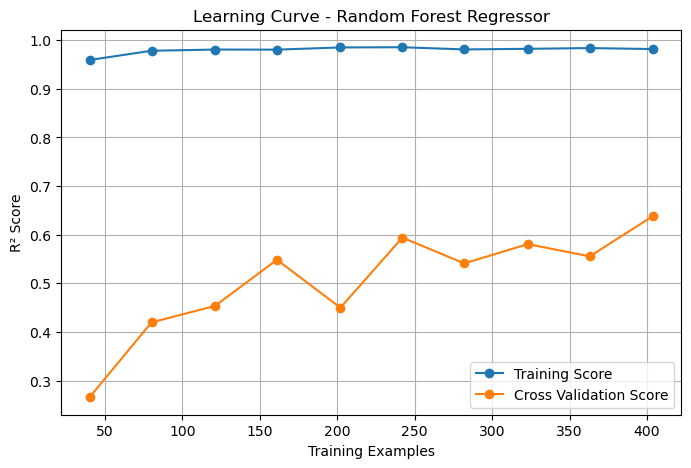

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = RandomForestRegressor(random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_housing_scaled,
    y_housing,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='o', label='Cross Validation Score')

plt.title("Learning Curve - Random Forest Regressor")
plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

svr_mae = mean_absolute_error(y_test, svr_preds)
svr_mse = mean_squared_error(y_test, svr_preds)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_preds)

print("Support Vector Regressor")
print("MAE:", svr_mae)
print("MSE:", svr_mse)
print("RMSE:", svr_rmse)
print("R² Score:", svr_r2)

Support Vector Regressor
MAE: 2.73276896493331
MSE: 25.693036656663203
RMSE: 5.068829910015053
R² Score: 0.6496425583214102


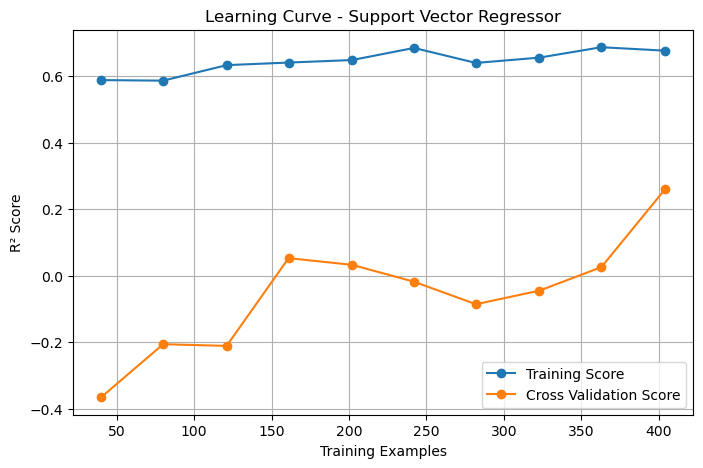

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.svm import SVR
import numpy as np

model = SVR()

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_housing_scaled,
    y_housing,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='o', label='Cross Validation Score')

plt.title("Learning Curve - Support Vector Regressor")
plt.xlabel("Training Examples")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()